In [ ]:
import torch
import torch.nn as nn
import math

class CustomLSTMCell(nn.Module):
    """
    A single LSTM cell implemented completely from scratch.
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(CustomLSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Combine all gate weights for efficiency: input, forget, cell, output
        self.W = nn.Parameter(torch.Tensor(4 * hidden_size, input_size))
        self.U = nn.Parameter(torch.Tensor(4 * hidden_size, hidden_size))
        self.b = nn.Parameter(torch.Tensor(4 * hidden_size))

        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)

    def forward(self, x: torch.Tensor, init_states=None):
        batch_size = x.size(0)

        if init_states is None:
            h_prev = torch.zeros(batch_size, self.hidden_size, device=x.device)
            c_prev = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h_prev, c_prev = init_states

        gates = torch.matmul(x, self.W.t()) + torch.matmul(h_prev, self.U.t()) + self.b
        i_gate, f_gate, c_tilde, o_gate = torch.chunk(gates, 4, dim=1)

        # Manual element-wise execution of gates and state updates
        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        c_tilde = torch.tanh(c_tilde)
        o_gate = torch.sigmoid(o_gate)

        c_next = f_gate * c_prev + i_gate * c_tilde
        h_next = o_gate * torch.tanh(c_next)

        return h_next, c_next


class CustomLSTMLayer(nn.Module):
    """
    Processes sequence input and returns sequence output (or final state).
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(CustomLSTMLayer, self).__init__()
        self.cell = CustomLSTMCell(input_size, hidden_size)

    def forward(self, x: torch.Tensor, return_sequences: bool = True):
        """
        x shape: (batch_size, sequence_length, input_size)
        """
        batch_size, seq_len, _ = x.size()
        hidden_size = self.cell.hidden_size

        h = torch.zeros(batch_size, hidden_size, device=x.device)
        c = torch.zeros(batch_size, hidden_size, device=x.device)

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            h, c = self.cell(x_t, (h, c))
            outputs.append(h.unsqueeze(1))

        if return_sequences:
            # Stack along sequence dimension: (batch_size, seq_len, hidden_size)
            return torch.cat(outputs, dim=1)
        else:
            # Return only last hidden state: (batch_size, hidden_size)
            return h


class StackedWeatherForecaster(nn.Module):
    """
    Weather Forecaster containing exactly 2 Stacked Manual LSTM Layers.
    """
    def __init__(self, num_features: int, hidden_size: int, output_timesteps: int = 12):
        super(StackedWeatherForecaster, self).__init__()

        # Layer 1: Takes raw features -> outputs sequence of hidden representations
        self.lstm1 = CustomLSTMLayer(input_size=num_features, hidden_size=hidden_size)

        # Layer 2: Takes sequence from Layer 1 -> outputs final hidden representation
        self.lstm2 = CustomLSTMLayer(input_size=hidden_size, hidden_size=hidden_size)

        # Output Linear Layer maps final hidden output to target future timesteps
        self.fc = nn.Linear(hidden_size, output_timesteps)

    def forward(self, x: torch.Tensor):
        # x shape: (batch_size, 72, num_features)

        # First layer returns full sequence representation
        out_seq1 = self.lstm1(x, return_sequences=True)

        # Second layer only needs to return the terminal hidden state vector
        out_final = self.lstm2(out_seq1, return_sequences=False)

        # Map to temperature forecast for the next 12 hours
        return self.fc(out_final)
if __name__ == "__main__":
    # Bounds constraint check
    HIDDEN_DIM = 128  # Chosen value strictly between 32 and 256
    assert 32 <= HIDDEN_DIM <= 256, "Hidden size must be between 32 and 256"

    BATCH_SIZE = 32
    INPUT_HOURS = 72
    OUTPUT_HOURS = 12
    NUM_FEATURES = 14

    # Instantiate Stacked model
    model = StackedWeatherForecaster(
        num_features=NUM_FEATURES,
        hidden_size=HIDDEN_DIM,
        output_timesteps=OUTPUT_HOURS
    )

    # Forward Pass Verification
    mock_input = torch.randn(BATCH_SIZE, INPUT_HOURS, NUM_FEATURES)
    predictions = model(mock_input)

    print(f"Model successfully loaded with 2 Custom LSTM layers (Hidden dimension: {HIDDEN_DIM})")
    print(f"Output dimension shape: {predictions.shape} (Expected: [{BATCH_SIZE}, {OUTPUT_HOURS}])")


Model successfully loaded with 2 Custom LSTM layers (Hidden dimension: 128)
Output dimension shape: torch.Size([32, 12]) (Expected: [32, 12])


LOAD JEENA CLIMATE DATESET

In [ ]:
import requests
import pandas as pd
import os
import zipfile

# Define the URL for the Jena Climate dataset
# Updated URL to a reliable source
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_file_name = "jena_climate_2009_2016.csv.zip"
csv_file_name = "jena_climate_2009_2016.csv"

# Download the file
print(f"Downloading {zip_file_name}...")
response = requests.get(url)

# Check if the request was successful
response.raise_for_status() # Raises an HTTPError for bad responses (4xx or 5xx)

with open(zip_file_name, "wb") as f:
    f.write(response.content)
print(f"Downloaded {zip_file_name}.")

# Unzip the file
print(f"Extracting {csv_file_name}...")
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')
print(f"Extracted {csv_file_name}.")

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_name)

print("Dataset loaded successfully.")

Downloaded jena_climate_2009_2016.csv.zip.
Extracting jena_climate_2009_2016.csv...
Extracted jena_climate_2009_2016.csv.
Dataset loaded successfully.


 I have downsample the data to hourly observations by averaging every 6 consecutive 10-minute readings. This process involves:

1.  Converting the 'Date Time' column to a proper datetime format.
2.  Setting the 'Date Time' column as the DataFrame index.
3.  Using the `resample()` method to group data by hour and `mean()` to calculate the average for each hour.

In [ ]:
# Convert 'Date Time' column to datetime objects
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Set 'Date Time' as the DataFrame index
df_indexed = df.set_index('Date Time')

# Resample to hourly data by taking the mean of every 6 consecutive 10-minute readings
df_hourly = df_indexed.resample('h').mean()

# Display the first few rows of the downsampled hourly DataFrame
print("Downsampled hourly DataFrame head:")
display(df_hourly.head())

# Display basic information about the downsampled DataFrame
print("\nDownsampled hourly DataFrame info:")
display(df_hourly.info())

Downsampled hourly DataFrame head:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333



Downsampled hourly DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70129 entries, 2009-01-01 00:00:00 to 2017-01-01 00:00:00
Freq: h
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   p (mbar)         70041 non-null  float64
 1   T (degC)         70041 non-null  float64
 2   Tpot (K)         70041 non-null  float64
 3   Tdew (degC)      70041 non-null  float64
 4   rh (%)           70041 non-null  float64
 5   VPmax (mbar)     70041 non-null  float64
 6   VPact (mbar)     70041 non-null  float64
 7   VPdef (mbar)     70041 non-null  float64
 8   sh (g/kg)        70041 non-null  float64
 9   H2OC (mmol/mol)  70041 non-null  float64
 10  rho (g/m**3)     70041 non-null  float64
 11  wv (m/s)         70041 non-null  float64
 12  max. wv (m/s)    70041 non-null  float64
 13  wd (deg)         70041 non-null  float64
dtypes: float64(14)
memory usage: 8.0 MB


None

### Data Cleaning and Normalization

 fill any missing values and normalize the data using a standard Z-score normalization. This is crucial for training LSTMs to ensure stable gradients and faster convergence.

In [ ]:
import numpy as np
import pandas as pd
import os
import requests
import zipfile

csv_path = 'jena_climate_2009_2016.csv'
zip_path = 'jena_climate_2009_2016.csv.zip'

# Ensure the dataframe 'df' is available, otherwise load/download it
if 'df' not in globals():
    if not os.path.exists(csv_path):
        if not os.path.exists(zip_path):
            print("Downloading dataset...")
            url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
            response = requests.get(url)
            response.raise_for_status()
            with open(zip_path, "wb") as f:
                f.write(response.content)

        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')

    globals()['df'] = pd.read_csv(csv_path)
    print("Dataset loaded successfully into 'df'.")

# Data processing
temp_df = df.copy()
temp_df['Date Time'] = pd.to_datetime(temp_df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_hourly = temp_df.set_index('Date Time').resample('h').mean()

# Updated: Using .bfill() instead of .fillna(method='bfill') to avoid FutureWarning
df_hourly = df_hourly.interpolate(method='linear').bfill()

# Normalize the features
data_values = df_hourly.values
mean = data_values.mean(axis=0)
std = data_values.std(axis=0)
globals()['mean'] = mean # Make mean globally accessible
globals()['std'] = std   # Make std globally accessible
globals()['data_normalized'] = (data_values - mean) / std

print(f"Normalized data shape: {data_normalized.shape}")

Normalized data shape: (70129, 14)


### Create PyTorch Dataset and DataLoader
 `WeatherDataset` class to create the windowed samples. We use 72 hours of data to predict the temperature ('T (degC)', which is index 1) for the next 12 hours.

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class WeatherDataset(Dataset):
    def __init__(self, data, input_width=72, label_width=12, target_col_idx=1):
        self.data = torch.FloatTensor(data)
        self.input_width = input_width
        self.label_width = label_width
        self.target_col_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.input_width - self.label_width

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_width]
        y = self.data[idx + self.input_width : idx + self.input_width + self.label_width, self.target_col_idx]
        return x, y

# Ensure data_normalized is accessible
if 'data_normalized' in globals():
    data_norm = globals()['data_normalized']
    INPUT_HOURS = 72
    OUTPUT_HOURS = 12
    BATCH_SIZE = 32

    n = len(data_norm)
    train_data = data_norm[0 : int(n * 0.7)]
    val_data = data_norm[int(n * 0.7) : int(n * 0.9)]

    globals()['train_loader'] = DataLoader(WeatherDataset(train_data, INPUT_HOURS, OUTPUT_HOURS), batch_size=BATCH_SIZE, shuffle=True)
    globals()['val_loader'] = DataLoader(WeatherDataset(val_data, INPUT_HOURS, OUTPUT_HOURS), batch_size=BATCH_SIZE)

    print(f'Train batches: {len(train_loader)}')
    print(f'Validation batches: {len(val_loader)}')
else:
    print("Error: 'data_normalized' not found. Please ensure cell e8682f9c has run.")

Train batches: 1532
Validation batches: 436


### Model Training

Train the model using Mean Squared Error (MSE) loss and the Adam optimizer. We will monitor the validation loss to ensure the model is learning effectively.

In [ ]:
import torch.optim as optim
import time
import torch
import torch.nn as nn
import math
import os
import requests
import zipfile
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# --- Upgraded 3-Layer Architecture ---
class CustomLSTMCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super(CustomLSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.W = nn.Parameter(torch.Tensor(4 * hidden_size, input_size))
        self.U = nn.Parameter(torch.Tensor(4 * hidden_size, hidden_size))
        self.b = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.init_weights()
    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)
    def forward(self, x: torch.Tensor, init_states=None):
        batch_size = x.size(0)
        if init_states is None:
            h_prev = torch.zeros(batch_size, self.hidden_size, device=x.device)
            c_prev = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h_prev, c_prev = init_states
        gates = torch.matmul(x, self.W.t()) + torch.matmul(h_prev, self.U.t()) + self.b
        i, f, c_t, o = torch.chunk(gates, 4, dim=1)
        c_next = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(c_t)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

class CustomLSTMLayer(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, dropout: float = 0.0):
        super(CustomLSTMLayer, self).__init__()
        self.cell = CustomLSTMCell(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x: torch.Tensor, return_sequences: bool = True):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        outputs = []
        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], (h, c))
            outputs.append(h.unsqueeze(1))
        out = torch.cat(outputs, dim=1) if return_sequences else h
        return self.dropout(out)

class StackedWeatherForecaster(nn.Module):
    def __init__(self, num_features: int, hidden_size: int, output_timesteps: int = 12, dropout: float = 0.2):
        super(StackedWeatherForecaster, self).__init__()
        self.lstm1 = CustomLSTMLayer(num_features, hidden_size, dropout=dropout)
        self.lstm2 = CustomLSTMLayer(hidden_size, hidden_size, dropout=dropout)
        self.lstm3 = CustomLSTMLayer(hidden_size, hidden_size, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_timesteps)
    def forward(self, x: torch.Tensor):
        out = self.lstm1(x, return_sequences=True)
        out = self.lstm2(out, return_sequences=True)
        out = self.lstm3(out, return_sequences=False)
        return self.fc(out)

# --- Robust Data Loading ---
if 'train_loader' not in globals() or 'data_normalized' not in globals():
    csv_path = 'jena_climate_2009_2016.csv'
    df_tmp = pd.read_csv(csv_path)
    df_tmp['Date Time'] = pd.to_datetime(df_tmp['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df_h = df_tmp.set_index('Date Time').resample('h').mean().interpolate().bfill()
    v = df_h.values
    globals()['mean'] = v.mean(axis=0)
    globals()['std'] = v.std(axis=0)
    globals()['data_normalized'] = (v - mean) / std

    class WeatherDataset(Dataset):
        def __init__(self, data, input_width=72, label_width=12, target_col_idx=1):
            self.data = torch.FloatTensor(data)
            self.input_width, self.label_width, self.target_col_idx = input_width, label_width, target_col_idx
        def __len__(self): return len(self.data) - self.input_width - self.label_width
        def __getitem__(self, idx):
            x = self.data[idx : idx + self.input_width]
            y = self.data[idx + self.input_width : idx + self.input_width + self.label_width, self.target_col_idx]
            return x, y

    dn = globals()['data_normalized']
    n = len(dn)
    globals()['train_loader'] = DataLoader(WeatherDataset(dn[:int(n*0.7)]), batch_size=32, shuffle=True)
    globals()['val_loader'] = DataLoader(WeatherDataset(dn[int(n*0.7):int(n*0.9)]), batch_size=32)

# --- Training Loop ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
globals()['model'] = StackedWeatherForecaster(num_features=14, hidden_size=160, dropout=0.2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=2e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
criterion = nn.MSELoss()

globals()['train_losses'], globals()['val_losses'] = [], []
epochs = 15
print(f"Training on {device}...")
try:
    for epoch in range(epochs):
        model.train()
        t_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                v_loss += criterion(model(inputs), targets).item()

        avg_t, avg_v = t_loss/len(train_loader), v_loss/len(val_loader)
        train_losses.append(avg_t)
        val_losses.append(avg_v)
        scheduler.step(avg_v)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_t:.4f}, Val Loss: {avg_v:.4f}")
except KeyboardInterrupt:
    print("Training interrupted by user.")

Training on cpu...
Epoch 1/15 - Train Loss: 0.1067, Val Loss: 0.0688
Epoch 2/15 - Train Loss: 0.0749, Val Loss: 0.0715
Epoch 3/15 - Train Loss: 0.0725, Val Loss: 0.0647
Epoch 4/15 - Train Loss: 0.0702, Val Loss: 0.0682
Epoch 5/15 - Train Loss: 0.0690, Val Loss: 0.0652
Epoch 6/15 - Train Loss: 0.0680, Val Loss: 0.0737
Epoch 7/15 - Train Loss: 0.0621, Val Loss: 0.0594
Epoch 8/15 - Train Loss: 0.0614, Val Loss: 0.0613
Epoch 9/15 - Train Loss: 0.0604, Val Loss: 0.0653
Epoch 10/15 - Train Loss: 0.0605, Val Loss: 0.0609
Epoch 11/15 - Train Loss: 0.0569, Val Loss: 0.0584
Epoch 12/15 - Train Loss: 0.0566, Val Loss: 0.0586
Epoch 13/15 - Train Loss: 0.0564, Val Loss: 0.0579
Epoch 14/15 - Train Loss: 0.0564, Val Loss: 0.0580
Epoch 15/15 - Train Loss: 0.0560, Val Loss: 0.0575


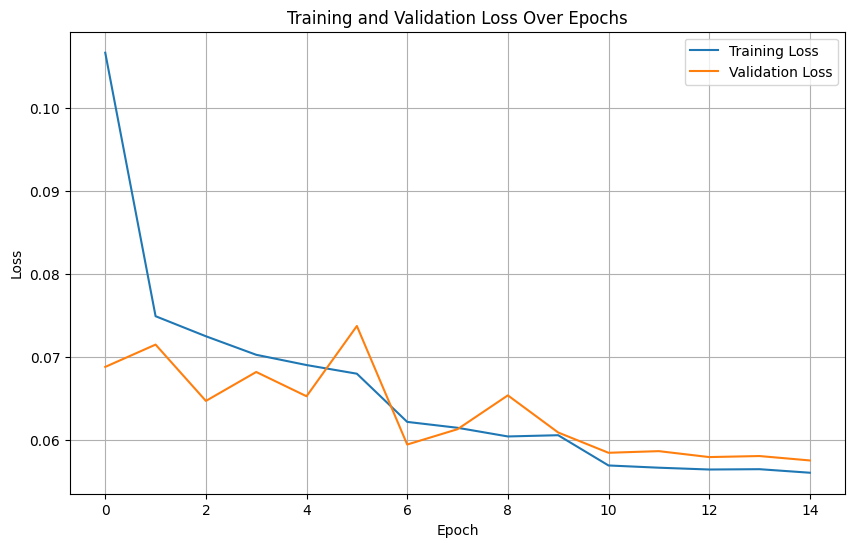

In [ ]:
import matplotlib.pyplot as plt

# Ensure train_losses and val_losses are available
if 'train_losses' in globals() and 'val_losses' in globals():
    # Plotting the training and validation loss curves
    fig = plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Training and validation losses are not available. Please ensure the training cell has been run.")

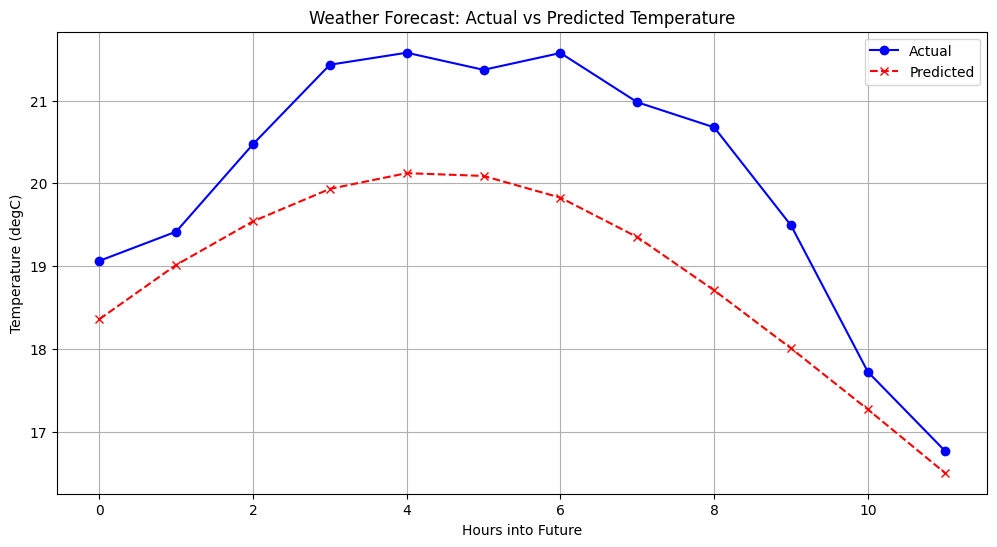

In [ ]:
import matplotlib.pyplot as plt
import torch

# The training has now finished, so these should be in globals()
if 'model' in globals() and 'val_loader' in globals():
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Get one batch
    inputs, targets = next(iter(val_loader))
    inputs, targets = inputs.to(device), targets.to(device)

    with torch.no_grad():
        predictions = model(inputs)

    # Select sample and denormalize
    actual_sample = targets[0].cpu().numpy()
    predicted_sample = predictions[0].cpu().numpy()

    target_col_idx = 1 # 'T (degC)'
    actual_mean = globals()['mean'][target_col_idx]
    actual_std = globals()['std'][target_col_idx]

    denormalized_actual = (actual_sample * actual_std) + actual_mean
    denormalized_predicted = (predicted_sample * actual_std) + actual_mean

    plt.figure(figsize=(12, 6))
    plt.plot(denormalized_actual, 'b-o', label='Actual')
    plt.plot(denormalized_predicted, 'r--x', label='Predicted')
    plt.title('Weather Forecast: Actual vs Predicted Temperature')
    plt.xlabel('Hours into Future')
    plt.ylabel('Temperature (degC)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Model or Data Loaders not found. Please ensure cell c1f91c1e finished execution.")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

OUTPUT_HOURS = 12 # Explicitly define OUTPUT_HOURS

# Ensure model, val_loader, mean, and std are available
# Re-run cell c1f91c1e if train_loader or model is not found.
if 'train_loader' not in globals() or 'model' not in globals() or 'mean' not in globals() or 'std' not in globals():
    print("Error: Required variables (model, val_loader, mean, std) are not defined. Please ensure previous cells have run.")
    # Optionally, re-run necessary setup here if needed, similar to c1f91c1e's self-contained logic.
else:
    model.eval() # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    all_predictions = []
    all_actuals = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            # Convert to numpy and denormalize
            predicted_batch = outputs.cpu().numpy()
            actual_batch = targets.cpu().numpy()

            # Denormalize using the mean and std of the target column ('T (degC)' (index 1)
            target_col_idx = 1 # Index of 'T (degC)'
            actual_mean = mean[target_col_idx]
            actual_std = std[target_col_idx]

            denormalized_predicted_batch = (predicted_batch * actual_std) + actual_mean
            denormalized_actual_batch = (actual_batch * actual_std) + actual_mean

            all_predictions.append(denormalized_predicted_batch)
            all_actuals.append(denormalized_actual_batch)

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions, axis=0)
    all_actuals = np.concatenate(all_actuals, axis=0)

    # Calculate metrics for each output timestep (each of the 12 hours)
    for i in range(OUTPUT_HOURS):
        mae = mean_absolute_error(all_actuals[:, i], all_predictions[:, i])
        mse = mean_squared_error(all_actuals[:, i], all_predictions[:, i])
        rmse = np.sqrt(mse)

        print(f"\nMetrics for Hour {i+1} into the future:")
        print(f"  MAE: {mae:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")

    # Calculate overall metrics by flattening the arrays
    overall_mae = mean_absolute_error(all_actuals.flatten(), all_predictions.flatten())
    overall_mse = mean_squared_error(all_actuals.flatten(), all_predictions.flatten())
    overall_rmse = np.sqrt(overall_mse)

    print("\n--- Overall Metrics (across all predicted hours) ---")
    print(f"Overall MAE: {overall_mae:.4f}")
    print(f"Overall MSE: {overall_mse:.4f}")
    print(f"Overall RMSE: {overall_rmse:.4f}")


Metrics for Hour 1 into the future:
  MAE: 0.5894
  MSE: 0.6271
  RMSE: 0.7919

Metrics for Hour 2 into the future:
  MAE: 0.8377
  MSE: 1.2830
  RMSE: 1.1327

Metrics for Hour 3 into the future:
  MAE: 1.0676
  MSE: 2.0507
  RMSE: 1.4320

Metrics for Hour 4 into the future:
  MAE: 1.2608
  MSE: 2.7978
  RMSE: 1.6727

Metrics for Hour 5 into the future:
  MAE: 1.4180
  MSE: 3.4801
  RMSE: 1.8655

Metrics for Hour 6 into the future:
  MAE: 1.5464
  MSE: 4.0983
  RMSE: 2.0244

Metrics for Hour 7 into the future:
  MAE: 1.6527
  MSE: 4.6455
  RMSE: 2.1553

Metrics for Hour 8 into the future:
  MAE: 1.7448
  MSE: 5.1382
  RMSE: 2.2668

Metrics for Hour 9 into the future:
  MAE: 1.8271
  MSE: 5.5896
  RMSE: 2.3642

Metrics for Hour 10 into the future:
  MAE: 1.9015
  MSE: 6.0123
  RMSE: 2.4520

Metrics for Hour 11 into the future:
  MAE: 1.9618
  MSE: 6.3791
  RMSE: 2.5257

Metrics for Hour 12 into the future:
  MAE: 2.0109
  MSE: 6.6976
  RMSE: 2.5880

--- Overall Metrics (across all pred

### Model Weights Analysis

In [ ]:
print("\n--- Model Weights Analysis ---")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name} | Size: {param.size()} | Mean: {param.data.mean():.4f} | Std: {param.data.std():.4f}")


--- Model Weights Analysis ---
Layer: lstm1.cell.W | Size: torch.Size([640, 14]) | Mean: -0.0006 | Std: 0.0433
Layer: lstm1.cell.U | Size: torch.Size([640, 160]) | Mean: 0.0002 | Std: 0.0145
Layer: lstm1.cell.b | Size: torch.Size([640]) | Mean: 0.0283 | Std: 0.0674
Layer: lstm2.cell.W | Size: torch.Size([640, 160]) | Mean: 0.0003 | Std: 0.0144
Layer: lstm2.cell.U | Size: torch.Size([640, 160]) | Mean: -0.0001 | Std: 0.0136
Layer: lstm2.cell.b | Size: torch.Size([640]) | Mean: 0.0263 | Std: 0.0611
Layer: lstm3.cell.W | Size: torch.Size([640, 160]) | Mean: -0.0001 | Std: 0.0134
Layer: lstm3.cell.U | Size: torch.Size([640, 160]) | Mean: 0.0002 | Std: 0.0093
Layer: lstm3.cell.b | Size: torch.Size([640]) | Mean: 0.0237 | Std: 0.0357
Layer: fc.weight | Size: torch.Size([12, 160]) | Mean: -0.0118 | Std: 0.0888
Layer: fc.bias | Size: torch.Size([12]) | Mean: -0.0290 | Std: 0.0077
